In [3]:
     import pandas as pd

# Load the dataset
url = "https://raw.githubusercontent.com/CunyLaguardiaDataAnalytics/datasets/refs/heads/master/311_Service_Requests_from_2019May.csv"
df = pd.read_csv(url)
df.head()

/tmp/ipykernel_9989/534305402.py:5: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url)


,Unique Key,Created Date,Closed Date,Agency,Complaint Type,Location Type,Incident Zip,Incident Address,Street Name,Address Type,...,Landmark,Facility Type,Status,Due Date,Resolution Description,BBL,Borough,Latitude,Longitude,Location
0,42680103,5/1/2019 0:00,5/16/2019 21:45,DEP,Water System,NaN,11420.0,127-16 111 AVENUE,111 AVENUE,ADDRESS,...,NaN,NaN,Closed,NaN,The Department of Environment Protection inspe...,4.116320e+09,QUEENS,40.682565,-73.814060,"(40.682565064146196, -73.81406015056832)"
1,42530481,5/1/2019 0:00,5/2/2019 0:00,DOHMH,Food Poisoning,Restaurant/Bar/Deli/Bakery,10011.0,207 WEST 14 STREET,WEST 14 STREET,ADDRESS,...,NaN,NaN,Closed,5/15/2019 22:17,Callers should contact the DOHMH Foodborne Ill...,1.007640e+09,MANHATTAN,40.738791,-74.000224,"(40.738790792032844, -74.00022373020307)"
2,42527619,5/1/2019 0:00,5/13/2019 0:00,DOHMH,Food Poisoning,Restaurant/Bar/Deli/Bakery,10025.0,2664 BROADWAY,BROADWAY,ADDRESS,...,NaN,NaN,Closed,5/15/2019 10:04,The Department of Health and Mental Hygiene wi...,1.018730e+09,MANHATTAN,40.798040,-73.969300,"(40.79804015465285, -73.96930001020544)"
3,42526597,5/1/2019 0:00,5/2/2019 0:00,DOHMH,Food Poisoning,Restaurant/Bar/Deli/Bakery,11208.0,624 SOUTH CONDUIT BOULEVARD,SOUTH CONDUIT BOULEVARD,ADDRESS,...,NaN,NaN,Closed,5/15/2019 17:27,The Department of Health and Mental Hygiene wi...,3.042380e+09,BROOKLYN,40.675905,-73.866660,"(40.67590510222738, -73.86665990579837)"
4,42526595,5/1/2019 0:00,5/2/2019 0:00,DOHMH,Food Poisoning,Restaurant/Bar/Deli/Bakery,11106.0,31-91 21 STREET,21 STREET,ADDRESS,...,NaN,NaN,Closed,5/15/2019 17:12,The Department of Health and Mental Hygiene wi...,4.005540e+09,QUEENS,40.765367,-73.931540,"(40.76536704921336, -73.93154011254339)"


In [5]:
# How many rows and columns are there
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 69637
Number of columns: 21


In [6]:
# What is the time range of this dataset
print("First date:", df["Created Date"].min())
print("Last date:", df["Created Date"].max())

First date: 5/1/2019 0:00
Last date: 5/9/2019 9:59


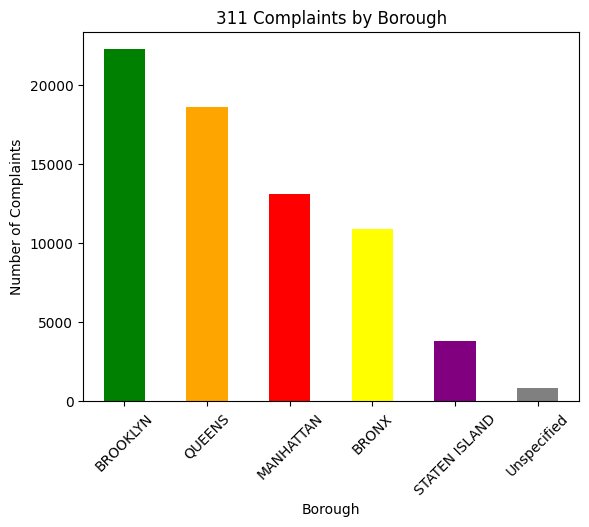

In [10]:
import matplotlib.pyplot as plt

# Vizualizations Parts or Summary Statistics
# 1- Complaints by borough

borough_colors = {
    "BROOKLYN": "green",
    "QUEENS": "orange",
    "MANHATTAN": "red",
    "BRONX": "yellow",
    "STATEN ISLAND": "purple",
    "Unspecified": "gray"
}

borough_counts = df["Borough"].value_counts()

borough_counts.plot(
    kind="bar",
    color=[borough_colors.get(borough, "gray") for borough in borough_counts.index]
)

plt.title("311 Complaints by Borough")
plt.xlabel("Borough")
plt.ylabel("Number of Complaints")
plt.xticks (rotation=45)
plt.show()

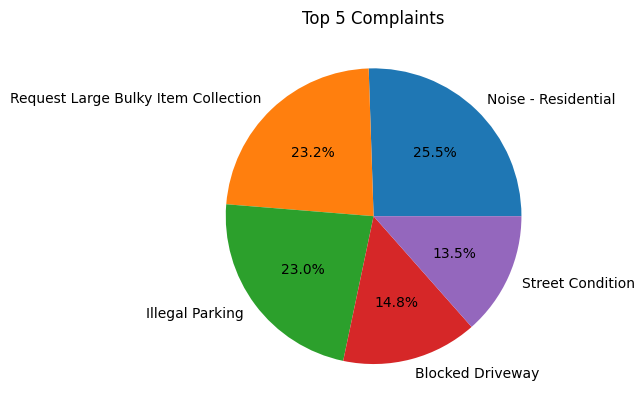

In [13]:
# 2- Top 5 complaints
top_complaints = df["Complaint Type"].value_counts().head(5)

top_complaints.plot(kind="pie", autopct='%1.1f%%')

plt.title("Top 5 Complaints")
plt.ylabel("")  # Oculta la etiqueta predeterminada del eje Y en gráficos de pastel
plt.show()

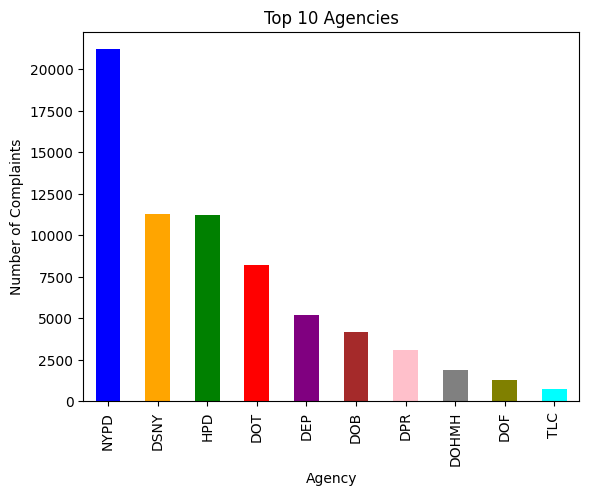

In [14]:
# Top 10 Agencies
top_agencies = df["Agency"].value_counts().head(10)

top_agencies.plot(
    kind="bar",
    color=["blue", "orange", "green", "red", "purple", "brown", "pink", "gray", "olive", "cyan"]
)

plt.title("Top 10 Agencies")
plt.xlabel("Agency")
plt.ylabel("Number of Complaints")
plt.show()

In [15]:
# 5- What borough has the most complaints?
print(df["Borough"].value_counts().head(1))

Borough
BROOKLYN    22247
Name: count, dtype: int64


In [19]:
# 6- Create a plot of counts by borough for noise complaints

# 1- Find the noise complaints
noise = df[df["Complaint Type"].str.contains("Noise", na=False)]

In [26]:
# 2- Count the Noise by borough and display as a formatted table
noise_borough_table = noise["Borough"].value_counts().reset_index()
noise_borough_table.columns = ["Borough", "Number of Complaints"]

# Display table
noise_borough_table

,Borough,Number of Complaints
0,MANHATTAN,3779
1,BROOKLYN,3294
2,QUEENS,2892
3,BRONX,2006
4,STATEN ISLAND,275
5,Unspecified,19


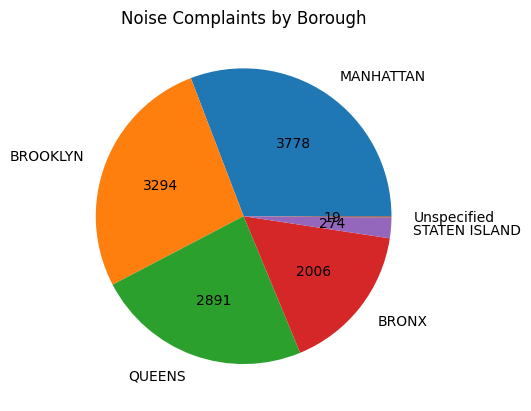

In [28]:


# 3- Make the noise graph (Pie Chart with exact counts)
noise_counts = noise["Borough"].value_counts()

noise_counts.plot(
    kind="pie",
    autopct=lambda p: int(p / 100 * noise_counts.sum()),
    labeldistance=1.15
)

plt.title("Noise Complaints by Borough")
plt.ylabel("")
plt.show()

In [29]:
# 7- Find one more interesting piece of information
df["Complaint Type"].value_counts().head(1)

,count
Complaint Type,
Noise - Residential,5838
